In [2]:
import os
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf


# Load base dataset
BASE_FILE = os.path.join("..", "..", "data", "processed", "cardio_onc_prostate_06_broad_clean.csv")

df = pd.read_csv(BASE_FILE)

print(df.shape)
df.head()

(239, 60)


,unique_patient_id,ethnicity,nht_auth_date,nht_start_date,bmi,specific_nht_used,age,adt_start_date,adt_agent,hx_smoking,...,bp_meds_post_binary,lipid_meds_post_binary,dm_meds_post_binary,at_risk,lifestyle_counseling,dm_severity,ethnicity_enc,specific_nht_used_enc,adt_agent_enc,prescribing_provider_enc
0,1.0,NaN,2022-01-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,27.0
1,2.0,NaN,2022-01-11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,27.0
2,3.0,Caucasian,2022-01-12,2022-02-01,25.99,Darolutamide,73.0,2018-01-26,Lupron,1.0,...,0.0,0.0,0.0,0.0,0,0.0,2.0,2.0,2.0,27.0
3,4.0,Asian,2022-01-14,2022-02-14,22.55,Apalutamide,93.0,2021-12-01,Bicalutamide,0.0,...,0.0,0.0,0.0,0.0,0,0.0,0.0,1.0,0.0,42.0
4,5.0,NaN,2022-01-19,NaN,NaN,Abiraterone,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0,NaN,NaN,0.0,NaN,7.0


In [3]:
# Ensure datetime
df["nht_start_date"] = pd.to_datetime(df["nht_start_date"], errors = "coerce")
df["adt_start_date"] = pd.to_datetime(df["adt_start_date"], errors = "coerce")

# Create time_to_nht (in days)
df["time_to_nht"] = (df["nht_start_date"] - df["adt_start_date"]).dt.days

# Check
print(df["time_to_nht"].describe())
print(df["time_to_nht"].isna().sum())

count      193.000000
mean       514.414508
std       3137.188715
min       -731.000000
25%          0.000000
50%         36.000000
75%        189.000000
max      42761.000000
Name: time_to_nht, dtype: float64
46


In [4]:
# Remove invalid values
df = df[df["time_to_nht"].notna()]
df = df[df["time_to_nht"] >= 0]  # remove negative durations

# Drop missing key predictors
df = df.dropna(subset = ["specific_nht_used", "adt_agent"])

print(df.shape)

(166, 61)


In [5]:
nht_summary = df.groupby("specific_nht_used")["time_to_nht"].agg(
    ["count", "mean", "median", "std"]
).sort_values("median")

print(nht_summary)

                   count         mean  median           std
specific_nht_used                                          
Abiraterone           81   193.259259    43.0    445.151738
Apalutamide           11   250.818182    47.0    494.457646
Darolutamide          57   545.947368    55.0   1003.705713
Enzalutamide          17  3057.000000   189.0  10264.112456


In [6]:
adt_summary = df.groupby("adt_agent")["time_to_nht"].agg(
    ["count", "mean", "median", "std"]
).sort_values("median")

print(adt_summary)

                                   count         mean  median          std
adt_agent                                                                 
Orgovyx                               65   118.815385    22.0   243.887647
Firmagon                              18    65.444444    35.5   102.938144
bicalutamide, then lupron              1    37.000000    37.0          NaN
Bicalutamide                          25  1921.880000    69.0  8522.459242
casodex to firmagon                    1    72.000000    72.0          NaN
casodex to lpron                       1   131.000000   131.0          NaN
casodex to lupron                      1   189.000000   189.0          NaN
Lupron                                46   811.586957   221.0  1130.169694
bicalutamide to lupron to orgovyx      2   250.000000   250.0   248.901587
bicalutamide + lupron                  1   392.000000   392.0          NaN
lupron, orgovyx (d/c)                  1   539.000000   539.0          NaN
lupron + bicalutamide    

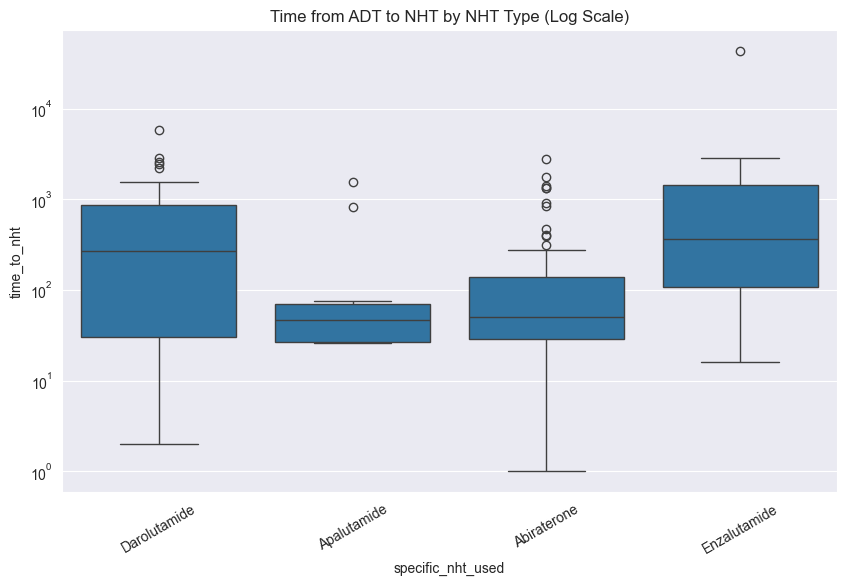

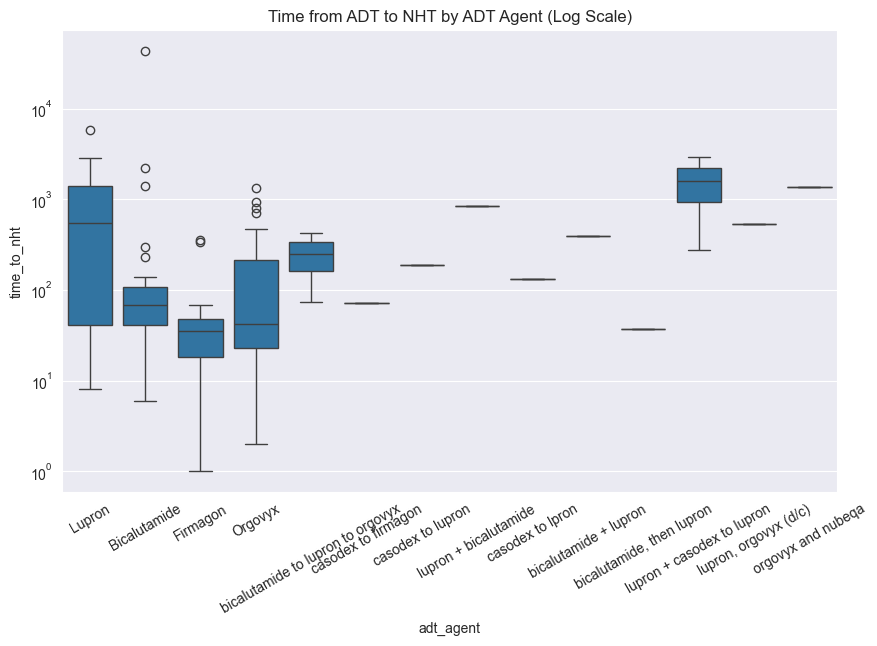

In [14]:
df_plot = df[df["time_to_nht"] > 0].copy()
plt.figure(figsize=(10,6))
sns.boxplot(data=df_plot, x="specific_nht_used", y="time_to_nht")
plt.yscale("log")
plt.title("Time from ADT to NHT by NHT Type (Log Scale)")
plt.xticks(rotation=30)
plt.show()

plt.figure(figsize=(10,6))
sns.boxplot(data=df_plot, x="adt_agent", y="time_to_nht")
plt.yscale("log")
plt.title("Time from ADT to NHT by ADT Agent (Log Scale)")
plt.xticks(rotation=30)
plt.show()

In [9]:
# Shapiro test (sample if large)
sample = df["time_to_nht"].dropna().sample(min(500, len(df)))

stat, p = stats.shapiro(sample)
print(f"Shapiro p-value: {p}")

Shapiro p-value: 4.905730523439788e-27


In [10]:
groups = [
    group["time_to_nht"].values
    for name, group in df.groupby("specific_nht_used")
]

stat, p = stats.kruskal(*groups)

print(f"Kruskal-Wallis (NHT): stat={stat:.3f}, p={p:.5f}")

Kruskal-Wallis (NHT): stat=3.183, p=0.36431


In [11]:
groups = [
    group["time_to_nht"].values
    for name, group in df.groupby("adt_agent")
]

stat, p = stats.kruskal(*groups)

print(f"Kruskal-Wallis (ADT): stat={stat:.3f}, p={p:.5f}")

Kruskal-Wallis (ADT): stat=40.221, p=0.00013


In [12]:
model = smf.ols("time_to_nht ~ C(specific_nht_used)", data = df).fit()
anova_table = sm.stats.anova_lm(model, typ = 2)

print(anova_table)

                            sum_sq     df         F    PR(>F)
C(specific_nht_used)  1.175129e+08    3.0  3.604801  0.014755
Residual              1.760346e+09  162.0       NaN       NaN


In [13]:
model = smf.ols(
    "time_to_nht ~ C(specific_nht_used) + C(adt_agent)",
    data = df
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            time_to_nht   R-squared:                       0.108
Model:                            OLS   Adj. R-squared:                  0.013
Method:                 Least Squares   F-statistic:                     1.133
Date:                Thu, 23 Apr 2026   Prob (F-statistic):              0.330
Time:                        00:14:10   Log-Likelihood:                -1574.1
No. Observations:                 166   AIC:                             3182.
Df Residuals:                     149   BIC:                             3235.
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                                                        coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------


# Analysis Summary: Time from ADT to NHT

## 1. Distribution and Data Quality

The outcome variable (`time_to_nht`) is highly right-skewed.

* Median: 36 days
* Mean: 514 days
* Standard deviation: 3137 days
* Minimum: -731 days (invalid temporal ordering)
* Maximum: 42,761 days (extreme outlier)

There are also negative values, indicating data quality or date ordering issues that should be addressed prior to final inference.

The Shapiro-Wilk test yields:

* p = 4.9e-27

This strongly rejects normality.

Conclusion:

* The distribution is non-normal and heavily influenced by outliers.
* Non-parametric tests (Kruskal-Wallis) are more appropriate than ANOVA or OLS for primary inference.

---

## 2. Differences in Time to NHT by NHT Type

### Descriptive patterns (medians)

* Abiraterone: 43 days
* Apalutamide: 47 days
* Darolutamide: 55 days
* Enzalutamide: 189 days

Enzalutamide appears to have a longer time to initiation, but this group also shows extreme variability.

### Statistical tests

* Kruskal-Wallis: p = 0.364
* ANOVA: p = 0.0148
* OLS regression (overall model): p = 0.33, R² = 0.108

Interpretation:

* The non-parametric test is not significant, indicating no robust evidence of differences in time to NHT across NHT classes.
* The ANOVA result is likely influenced by skewness and outliers and should not be prioritized.
* Overall, NHT class does not appear to be a strong determinant of time to initiation.

---

## 3. Differences in Time to NHT by ADT Agent

### Descriptive patterns (medians)

* Orgovyx: 22 days
* Firmagon: 35.5 days
* Lupron: 221 days
* Bicalutamide: 69 days (but with extreme variability)

### Statistical test

* Kruskal-Wallis: p = 0.00013

This is statistically significant.

Interpretation:

* There is strong evidence that time to NHT differs by ADT agent.

### Regression results

* Orgovyx is significantly associated with earlier NHT initiation (negative coefficient, p = 0.015).
* Lupron trends toward later initiation but is not consistently significant across all comparisons.
* Several combination or transition ADT categories show unstable estimates due to very small sample sizes.

Conclusion:

* ADT selection is significantly associated with timing to escalation to NHT.
* This effect appears stronger and more robust than NHT classification itself.

---

## 4. Multivariable Regression Model

* R² = 0.108
* Overall model p = 0.33

Interpretation:

* The model explains only a small proportion of variance in time to NHT.
* Neither ADT nor NHT variables fully account for timing differences.
* Important unmeasured confounders likely include:

  * Disease severity (e.g., stage, PSA, metastatic burden)
  * Insurance and access factors
  * Provider practice patterns
  * Clinical trial participation

---

## 5. Key Clinical Insights

### 1. No robust NHT-level timing differences

There is no statistically significant evidence that specific NHT agents are systematically started earlier or later when using appropriate non-parametric testing.

### 2. Strong ADT-associated variation

ADT choice is significantly associated with time to escalation to NHT. Patients on Orgovyx show consistently earlier transitions compared with other ADT agents.

### 3. Timing is weakly explained by measured covariates

Low R² indicates that observed variables do not capture most of the variability in treatment escalation timing.

---

## 6. Interpretation

Overall, the results suggest that treatment sequencing variability is more strongly associated with ADT selection than with the choice of NHT. This likely reflects underlying clinical decision pathways, where ADT selection serves as a marker of disease context or treatment strategy rather than directly influencing escalation timing.

---

## 7. Limitations

* Presence of negative and extreme time values suggests data quality issues.
* Strong right-skew and outliers distort mean-based analyses.
* Small sample sizes in several ADT subgroups reduce stability of estimates.
* Lack of disease severity and staging variables limits causal interpretation.
* Observational design prevents inference about treatment decision causality.
